In [40]:
import pandas as pd
df = pd.read_csv("ClimateTest.csv")

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          114 non-null    object 
 1   meantemp      114 non-null    float64
 2   humidity      114 non-null    float64
 3   wind_speed    114 non-null    float64
 4   meanpressure  114 non-null    float64
dtypes: float64(4), object(1)
memory usage: 4.6+ KB


In [42]:
df['date'] = pd.to_datetime(df['date'])

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          114 non-null    datetime64[ns]
 1   meantemp      114 non-null    float64       
 2   humidity      114 non-null    float64       
 3   wind_speed    114 non-null    float64       
 4   meanpressure  114 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 4.6 KB


In [44]:
from sklearn.preprocessing import MinMaxScaler

df = df.sort_values('date')
df = df.set_index('date')
train_values = df["meantemp"].values.reshape(-1, 1)
test_values = df["meantemp"].values.reshape(-1, 1)

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_values)
test_scaled = scaler.transform(test_values)

In [45]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
for train_index, test_index in tscv.split(df):
    train_data = df.iloc[train_index]
    test_data = df.iloc[test_index]

In [46]:
import numpy as np
def create_sequences(data, window=10):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])
    return np.array(X), np.array(y)
X_train, y_train = create_sequences(train_scaled, window=10)
combined = np.concatenate((train_scaled[-10:], test_scaled), axis=0)
X_test, y_test = create_sequences(combined, window=10)

In [119]:
import torch
import torch.nn as nn

def to_tensor(x):
    if isinstance(x, torch.Tensor):
        return x.clone().detach().float()
    else:
        return torch.tensor(x, dtype=torch.float32)

X_train = to_tensor(X_train)
y_train = to_tensor(y_train)
X_test = to_tensor(X_test)
y_test = to_tensor(y_test)

class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=256, num_layers=2):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out
loss_fn = nn.MSELoss()
model = RNNModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 30

for epoch in range(epochs):
    model.train()

    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.2571
Epoch 1, Loss: 0.0652
Epoch 2, Loss: 0.1562
Epoch 3, Loss: 0.0534
Epoch 4, Loss: 0.0674
Epoch 5, Loss: 0.0783
Epoch 6, Loss: 0.0658
Epoch 7, Loss: 0.0459
Epoch 8, Loss: 0.0340
Epoch 9, Loss: 0.0393
Epoch 10, Loss: 0.0426
Epoch 11, Loss: 0.0275
Epoch 12, Loss: 0.0157
Epoch 13, Loss: 0.0169
Epoch 14, Loss: 0.0208
Epoch 15, Loss: 0.0149
Epoch 16, Loss: 0.0096
Epoch 17, Loss: 0.0192
Epoch 18, Loss: 0.0135
Epoch 19, Loss: 0.0069
Epoch 20, Loss: 0.0092
Epoch 21, Loss: 0.0124
Epoch 22, Loss: 0.0126
Epoch 23, Loss: 0.0106
Epoch 24, Loss: 0.0087
Epoch 25, Loss: 0.0090
Epoch 26, Loss: 0.0102
Epoch 27, Loss: 0.0096
Epoch 28, Loss: 0.0072
Epoch 29, Loss: 0.0062


In [120]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

model.eval()

with torch.no_grad():
    y_pred = model(X_test)

y_pred = y_pred.cpu().numpy()
y_true = y_test.cpu().numpy()

y_pred = scaler.inverse_transform(y_pred)
y_true = scaler.inverse_transform(y_true)

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f"MSE {mse}")
print(f"MAE {mae}")

MSE 6.7733378410339355
MAE 1.8499988317489624


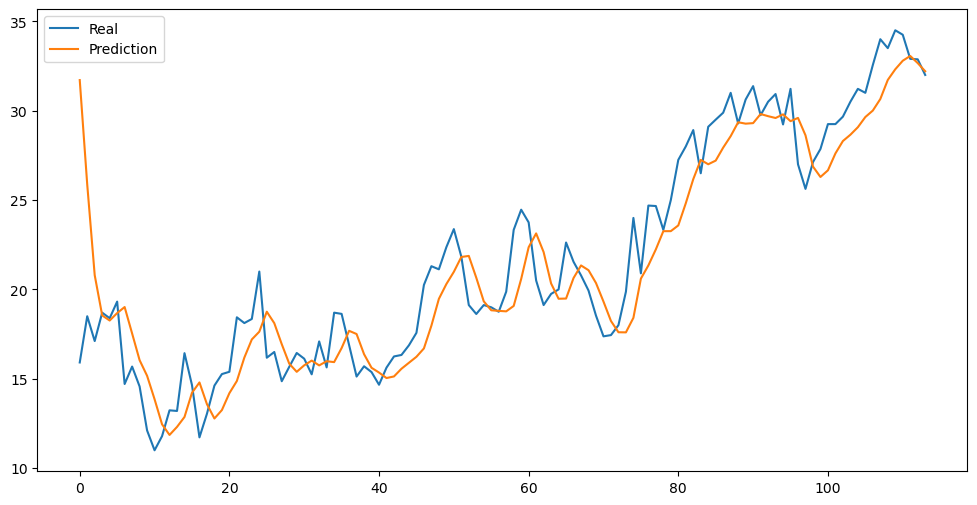

In [122]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(y_true, label="Real")
plt.plot(y_pred, label="Prediction")
plt.savefig("prediction_plot.png") 
plt.legend()
plt.show()

In [126]:
# to compare it with rnn model making a lstm model
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out
loss_fn = nn.MSELoss()
model = LSTMModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 30

for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.3347
Epoch 1, Loss: 0.2914
Epoch 2, Loss: 0.2497
Epoch 3, Loss: 0.2088
Epoch 4, Loss: 0.1681
Epoch 5, Loss: 0.1282
Epoch 6, Loss: 0.0914
Epoch 7, Loss: 0.0636
Epoch 8, Loss: 0.0587
Epoch 9, Loss: 0.0857
Epoch 10, Loss: 0.0966
Epoch 11, Loss: 0.0824
Epoch 12, Loss: 0.0646
Epoch 13, Loss: 0.0545
Epoch 14, Loss: 0.0524
Epoch 15, Loss: 0.0547
Epoch 16, Loss: 0.0581
Epoch 17, Loss: 0.0606
Epoch 18, Loss: 0.0612
Epoch 19, Loss: 0.0597
Epoch 20, Loss: 0.0564
Epoch 21, Loss: 0.0517
Epoch 22, Loss: 0.0464
Epoch 23, Loss: 0.0415
Epoch 24, Loss: 0.0381
Epoch 25, Loss: 0.0370
Epoch 26, Loss: 0.0380
Epoch 27, Loss: 0.0391
Epoch 28, Loss: 0.0380
Epoch 29, Loss: 0.0341


In [127]:
model.eval()

with torch.no_grad():
    y_pred = model(X_test)

y_pred = y_pred.cpu().numpy()
y_true = y_test.cpu().numpy()

y_pred = scaler.inverse_transform(y_pred)
y_true = scaler.inverse_transform(y_true)

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f"MSE {mse}")
print(f"MAE {mae}")

MSE 23.452850341796875
MAE 3.968684434890747


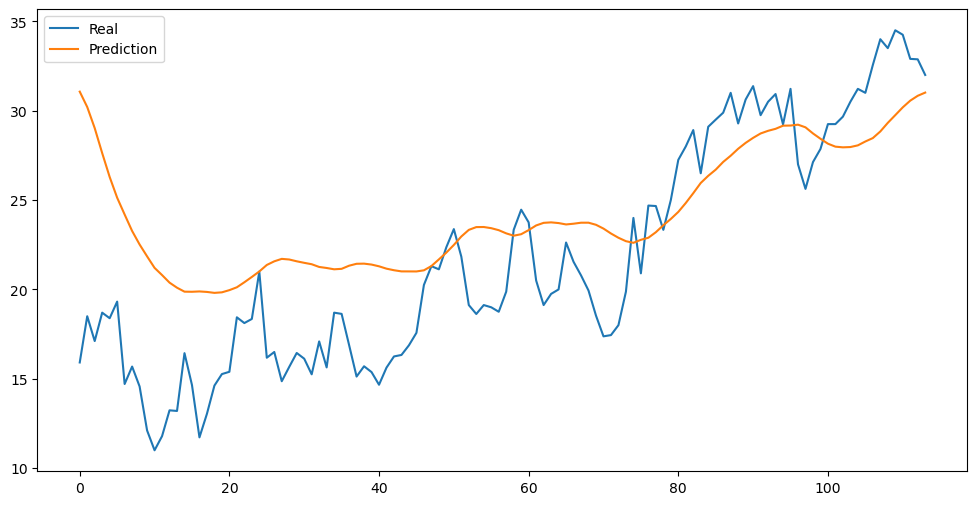

In [128]:
plt.figure(figsize=(12,6))
plt.plot(y_true, label="Real")
plt.plot(y_pred, label="Prediction")
plt.legend()
plt.show()

In [132]:
# had a GRU model also
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out
loss_fn = nn.MSELoss()
model = LSTMModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 30

for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.2929
Epoch 1, Loss: 0.2564
Epoch 2, Loss: 0.2224
Epoch 3, Loss: 0.1897
Epoch 4, Loss: 0.1579
Epoch 5, Loss: 0.1268
Epoch 6, Loss: 0.0976
Epoch 7, Loss: 0.0734
Epoch 8, Loss: 0.0621
Epoch 9, Loss: 0.0745
Epoch 10, Loss: 0.0904
Epoch 11, Loss: 0.0856
Epoch 12, Loss: 0.0718
Epoch 13, Loss: 0.0609
Epoch 14, Loss: 0.0563
Epoch 15, Loss: 0.0561
Epoch 16, Loss: 0.0577
Epoch 17, Loss: 0.0594
Epoch 18, Loss: 0.0601
Epoch 19, Loss: 0.0594
Epoch 20, Loss: 0.0571
Epoch 21, Loss: 0.0536
Epoch 22, Loss: 0.0491
Epoch 23, Loss: 0.0443
Epoch 24, Loss: 0.0401
Epoch 25, Loss: 0.0374
Epoch 26, Loss: 0.0368
Epoch 27, Loss: 0.0375
Epoch 28, Loss: 0.0369
Epoch 29, Loss: 0.0335


In [133]:
model.eval()

with torch.no_grad():
    y_pred = model(X_test)

y_pred = y_pred.cpu().numpy()
y_true = y_test.cpu().numpy()

y_pred = scaler.inverse_transform(y_pred)
y_true = scaler.inverse_transform(y_true)

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f"MSE {mse}")
print(f"MAE {mae}")

MSE 24.063701629638672
MAE 3.935045003890991


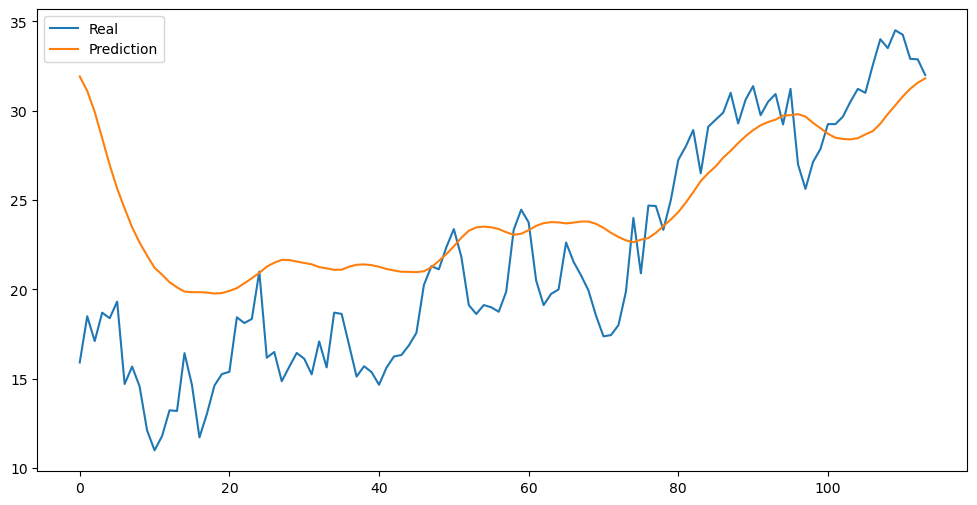

In [134]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(y_true, label="Real")
plt.plot(y_pred, label="Prediction")
plt.legend()
plt.show()